In [ ]:
cd tumbling_git

/share/nas2/pryder/tumbling_git


In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
freq = 1295e6
c= 299792458

## Autocorrelation

In [4]:
# spectrogram = np.load('/share/nas2/pryder/tumbling_git/exploring_parameters_results/spectrogram_intelsat_128_64.npy')
spec_0 = np.load('./spectrogram___intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_1 = np.load('./spectrogram_a_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_2 = np.load('./spectrogram_b_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')
spec_3 = np.load('./spectrogram_c_intelsat_128cpi_1sampoverlap_tukey_128pad_106_strips.npy')

In [5]:
zeros = np.zeros((256, 10))
combined_spec = np.hstack((spec_0, spec_1, spec_2, spec_3))
combined_spec.shape

(256, 424)

In [6]:
max_velocity = c / (4 * 19.7e-3* (freq))

#### Checking what the spectrogram looks like

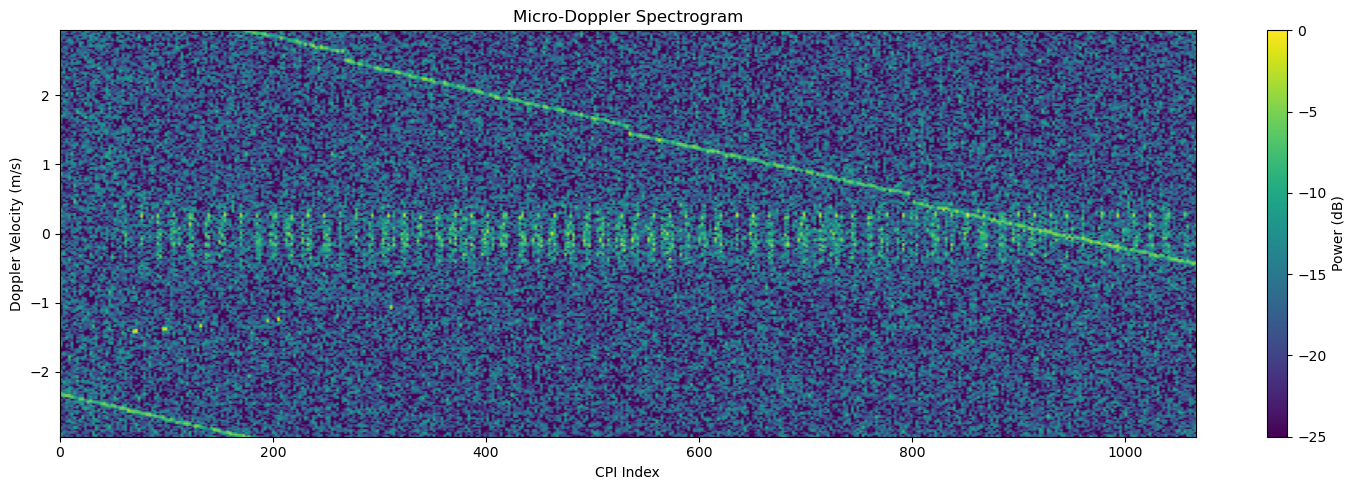

In [ ]:
plt.figure(figsize=(15, 5))
plt.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity])
# plt.title("Micro-Doppler Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Doppler Velocity (m/s)")
plt.colorbar(label='Power (dB)')
plt.tight_layout()

#### Now performing autocorrelation row wise on spectrogram. 

In [9]:
spectrogram = combined_spec

In [14]:
autocorrelation = np.zeros_like(spectrogram)
for n in range(spectrogram.shape[1]):
    row = spectrogram[:, n]
    print(len(row))
    print(len(autocorrelation[:, n]))
    autocorrelation[:, n] = np.correlate(row, row)

autocorrelation = np.sum(autocorrelation, axis=1)

256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256
256


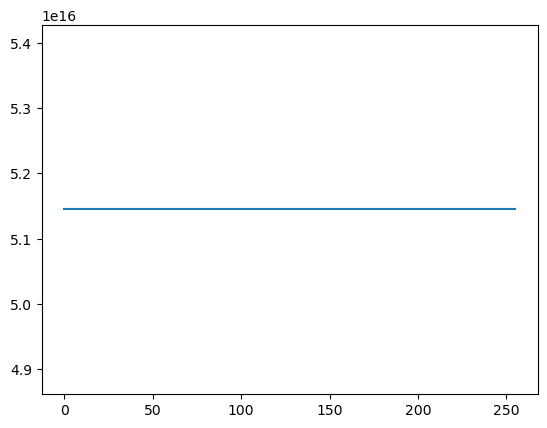

In [15]:
plt.plot(autocorrelation)
plt.show()

## Lomb-Scargle Periodogram

In [7]:
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks

In [73]:
summed_spec = np.sum(spectrogram, axis=0)
time = np.arange(spectrogram.shape[1])*19.7e-3*128
vel = np.linspace(-max_velocity, max_velocity, 256)

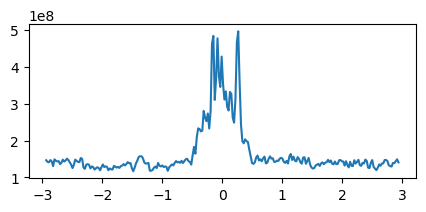

In [67]:
plt.figure(figsize=(5, 2))

plt.plot(vel, summed_spec)

In [68]:
vel_tip = vel[np.argmax(summed_spec)]
vel_tip

np.float64(0.2649795587764534)

In [74]:
frequency, power = LombScargle(time, summed_spec).autopower(method = 'slow', nyquist_factor=1)

Text(0.5, 0, 'Frequency (Hz)')

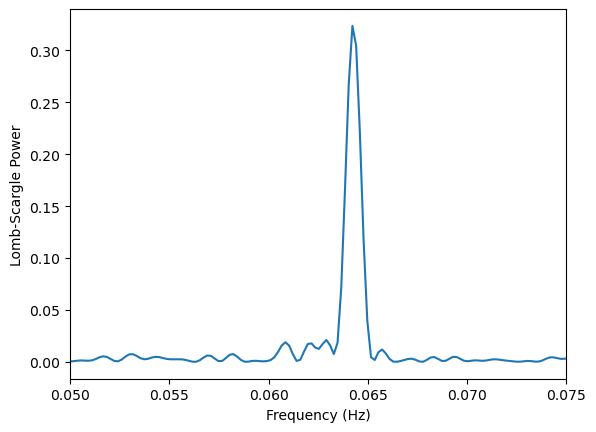

In [55]:
fig, ax = plt.subplots()
ax.plot(frequency, power)
ax.set_xlim(0.05, 0.075)
plt.ylabel('Lomb-Scargle Power')
plt.xlabel('Frequency (Hz)')

In [81]:
from scipy.optimize import curve_fit

def gaussian(x, A, mu, sigma):
    beamwidth = 0.106
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def single_gaussian_fitter(f, p, init_mu, init_sigma, target_name):
    
    # power_range = np.sum(data[:, start_range:end_range], axis=1)
    popt, pcov = curve_fit(gaussian, f, p, p0=[max(p), init_mu, init_sigma])
    A, mu, sigma = popt

    errors = np.sqrt(np.diag(pcov))
    mu_err = errors[1]
    # sigma_err = errors[2]

    x_fit = f
    y_fit = gaussian(f, *popt)
    print('Peak offset = ', mu, 'Hz')
    print('Error = ±', mu_err, 'Hz')
    print('Width = ', sigma, 'Hz')
    print('percentage error', sigma/frequency[np.argmax(power)]*100, '%')
    plt.plot(f, p, label = 'observation')
    plt.plot(x_fit, y_fit, label="Gaussian fit", color ='r')
    plt.xlim(0.05, 0.075)
    plt.xlabel('Frequency')
    plt.ylabel('Power')
    plt.title(target_name)
    plt.legend()
    plt.show()

Peak offset =  0.06426939907499521 Hz
Error = ± 6.496801995959935e-06 Hz
Width =  0.0003527810727432745 Hz
percentage error 0.5493274080751146 %


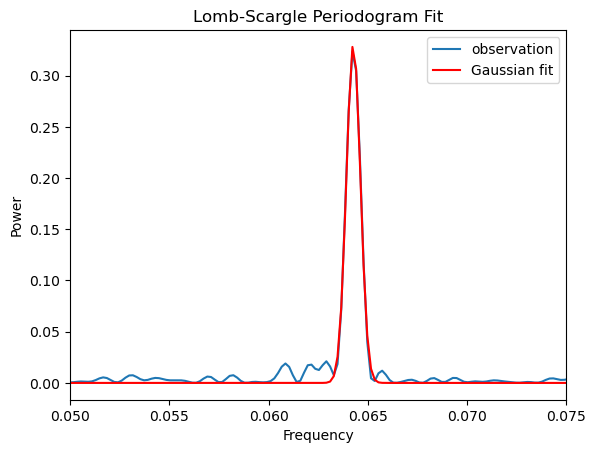

In [82]:
single_gaussian_fitter(frequency, power, frequency[np.argmax(power)], 0.0001, 'Lomb-Scargle Periodogram Fit')

In [88]:
peaks =find_peaks(power, height=np.max(power)*0.1)
peak_freqs = frequency[peaks[0]]
print("Peak frequencies (Hz):", peak_freqs)
print("Corresponding periods (s):", 1/peak_freqs[0])

Peak frequencies (Hz): [0.06422055 0.12853485 0.19266164]
Corresponding periods (s): 15.571340145985403


In [84]:
((0.5493274080751146)/100)*15.57134015

0.08553763924855465

In [85]:
v = vel_tip
print('Corresponding lengths (cm):', ((v*(1/peak_freqs))/(2*np.pi)*100)[0])

Corresponding lengths (cm): 65.66871164418062


In [89]:
((v*((1/peak_freqs[0])+0.09))/(2*np.pi)*100) - ((v*(1/peak_freqs[0]))/(2*np.pi)*100)

np.float64(0.3795552593782503)

TypeError: 'NoneType' object is not callable

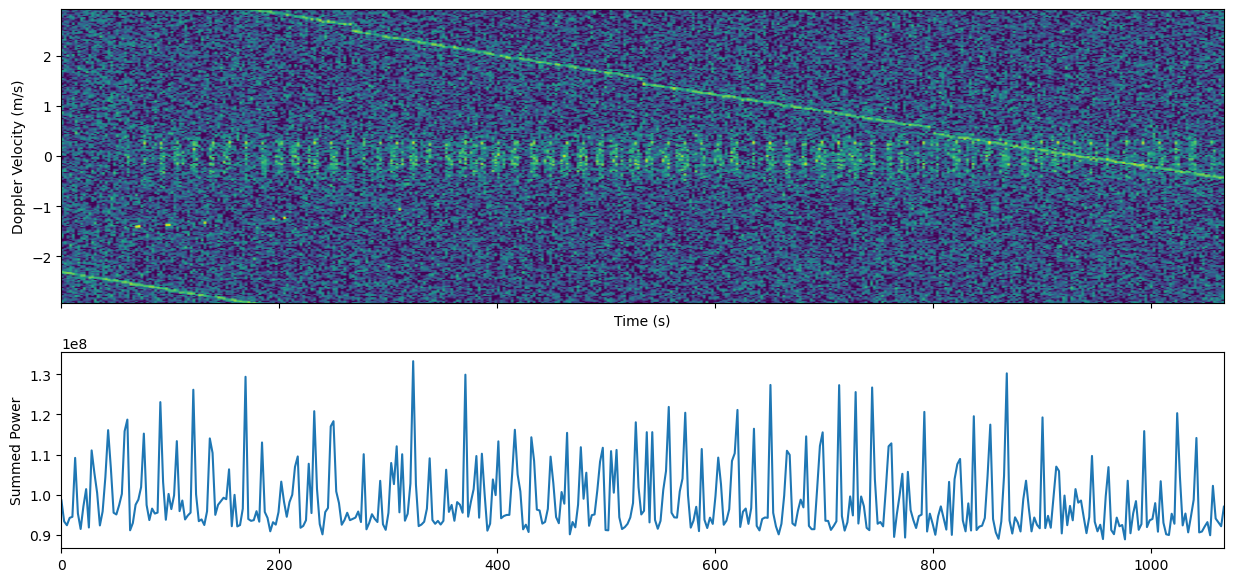

In [44]:
# --- 1. Setup the figure and subplots ---
# sharex=True aligns the x-axes perfectly
# gridspec_kw adjusts the height ratio so the spectrogram is taller
fig, (ax2, ax1) = plt.subplots(
    2, 1, figsize=(15, 7), sharex=True, gridspec_kw={"height_ratios": [3, 2]}
)

# --- 2. Top Plot: Line plot (summed_spec) ---
ax1.plot(time, summed_spec)
ax1.set_ylabel("Summed Power")  # Add a label for clarity
# ax1.set_title("Micro-Doppler Spectrogram Analysis") # Optional title


im = ax2.imshow(10 * np.log10(combined_spec+1e-12)-np.max(10 * np.log10(combined_spec+1e-12)), aspect='auto', origin='lower', vmin=-25, vmax=0, extent= [0, time[-1], -max_velocity, max_velocity])

ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Doppler Velocity (m/s)")
im.colorbar(label='Power (dB)', ax=ax2)




plt.tight_layout()
plt.show()

In [18]:
print(power.max())

0.32365802432624485


In [19]:
ls = LombScargle(time, summed_spec)

In [71]:
fap = ls.false_alarm_probability(power.max(), method='bootstrap')
fap

np.float64(0.0)

In [22]:
probabilities = [0.1, 0.05, 0.01]
ls.false_alarm_level(probabilities)


array([0.04832958, 0.05174   , 0.05938002])